# **Project Name**    -



##### **Project Type**    - EDA + Regression | Predictive Analytics
##### **Contribution**    - Individual


# **Project Summary -**

MovieIQ — Predictive Analytics on Film Success is a machine learning project that analyzes movie performance using key factors such as budget, revenue, popularity, runtime, and audience ratings. The project defines a movie as successful when its revenue is greater than its budget.

The project involves data preparation, exploratory data analysis, statistical testing, and a Random Forest classification model to predict whether a movie is likely to be successful. The analysis is then integrated into an interactive Streamlit dashboard, allowing users to explore movie trends and enter movie details to receive a success prediction.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


Movie success is influenced by multiple factors, and it can be difficult for studios or investors to assess the potential success of a movie before release.

The problem addressed by MovieIQ is:

To analyze historical movie performance data and develop a machine learning model that predicts whether a movie will be successful based on available performance indicators such as budget, popularity, runtime, and vote average.

For this project, success is explicitly defined as:

Revenue > Budget → Successful (1)
Revenue ≤ Budget → Not Successful (0)

#### **Define Your Business Objective?**

Identify factors associated with movie success and build a Random Forest classification model integrated into a Streamlit dashboard to support data-driven film investment and planning decisions.

To provide a data-driven solution that helps movie industry stakeholders assess the likelihood of a movie's financial success and make better-informed decisions.

Specifically, MovieIQ aims to:
1. Identify factors associated with movie success
   Budget, Popularity, Runtime, Vote average, Genre
2. Analyze historical movie performance
   Revenue patterns, Genre trends, Ratings, Popularity, Budget-revenue relationships
3. Statistically validate observed patterns
   T-test, Chi-square test
4. Build a predictive model
   Random Forest Classifier, Predict Successful vs Not Successful
5. Provide an interactive decision-support tool
   Streamlit dashboard, Genre and rating filters, Model performance, Movie success prediction

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 20 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from scipy.stats import ttest_ind, chi2_contingency

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings("ignore")

### Dataset Loading

In [2]:
# Load Dataset
df = pd.read_csv("C:/Users/Harika challa/Innovexis/Project-11/MovieIQ_Predictive_Analysis_on_Film_Success/Data/movies.csv")


### Dataset First View

In [3]:
# Dataset First Look
display(df.head())

,budget,revenue,popularity,runtime,vote_average,title,genres
0,57755036,107323371,60.377360,98,6.611888,Movie 1,"[{'id': 10749, 'name': 'Romance'}]"
1,192100010,342896533,86.289857,96,7.184687,Movie 2,"[{'id': 18, 'name': 'Drama'}]"
2,128521863,253206827,86.995324,148,3.542978,Movie 3,"[{'id': 35, 'name': 'Comedy'}]"
3,156299516,89635602,72.710096,118,5.985176,Movie 4,"[{'id': 18, 'name': 'Drama'}]"
4,148532820,221133868,74.829585,161,4.578480,Movie 5,"[{'id': 35, 'name': 'Comedy'}]"


### Dataset Rows & Columns count

In [4]:
# Dataset Rows & Columns count
print("Dataset Rows & Columns:", df.shape)

Dataset Rows & Columns: (2000, 7)


### Dataset Information

In [5]:
# Dataset Info
print("\nDataset Information:")
df.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   budget        2000 non-null   int64  
 1   revenue       2000 non-null   int64  
 2   popularity    2000 non-null   float64
 3   runtime       2000 non-null   int64  
 4   vote_average  2000 non-null   float64
 5   title         2000 non-null   object 
 6   genres        2000 non-null   object 
dtypes: float64(2), int64(3), object(2)
memory usage: 109.5+ KB


#### Duplicate Values

In [6]:
# Dataset Duplicate Value Count
print("Duplicate rows:", df.duplicated().sum())

# Check duplicate movie titles
print("Duplicate titles:", df['title'].duplicated().sum())


Duplicate rows: 0
Duplicate titles: 0


In [7]:
#Checking zero values for budget and revenue columns
print("Zero values in budget:", (df['budget'] == 0).sum())
print("Zero values in revenue:", (df['revenue'] == 0).sum())

Zero values in budget: 0
Zero values in revenue: 0


In [8]:
# Checking negative values
print("Negative values in budget:", (df['budget'] < 0).sum())
print("Negative values in revenue:", (df['revenue'] < 0).sum())

Negative values in budget: 0
Negative values in revenue: 0


#### Missing Values/Null Values

In [9]:
# Missing Values/Null Values Count

# Checking missing values
missing_values = df.isnull().sum()

missing_percentage = (
    df.isnull().mean() * 100
).round(2)

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": missing_percentage
})

display(missing_summary)

,Missing Values,Missing Percentage
budget,0,0.0
revenue,0,0.0
popularity,0,0.0
runtime,0,0.0
vote_average,0,0.0
title,0,0.0
genres,0,0.0


### What did you know about your dataset?

I worked with a dataset containing 2,000 movie records and seven initial columns: budget, revenue, popularity, runtime, vote average, title, and genres.

## ***2. Understanding Your Variables***

In [10]:
# Dataset Columns
# Inspecting the columns in the DataFrame
print("Columns:")
print(df.columns.tolist())


Columns:
['budget', 'revenue', 'popularity', 'runtime', 'vote_average', 'title', 'genres']


In [11]:
# Dataset Describe
# Summary statistics
numeric_columns = [
    "budget",
    "revenue",
    "popularity",
    "runtime",
    "vote_average"
]

display(df[numeric_columns].describe().T)

,count,mean,std,min,25%,50%,75%,max
budget,2000.0,1.019211e+08,5.682795e+07,1.070640e+06,5.274832e+07,1.026023e+08,1.507962e+08,1.999879e+08
revenue,2000.0,1.780574e+08,1.293879e+08,1.138729e+06,7.458306e+07,1.484882e+08,2.623679e+08,5.744901e+08
popularity,2000.0,5.009074e+01,2.848210e+01,1.018466e+00,2.572078e+01,5.021040e+01,7.492535e+01,9.976466e+01
runtime,2000.0,1.295680e+02,2.890651e+01,8.000000e+01,1.040000e+02,1.300000e+02,1.550000e+02,1.790000e+02
vote_average,2000.0,6.036764e+00,1.743093e+00,3.008133e+00,4.583298e+00,6.052901e+00,7.577305e+00,8.998509e+00


### Variables Description

| Variable         | Data Type | Description                                                                              | Role                  |
| ---------------- | --------- | ---------------------------------------------------------------------------------------- | --------------------- |
| **budget**       | Integer   | Production budget spent to make the movie, in currency units.                            | Predictor             |
| **revenue**      | Integer   | Total revenue generated by the movie.                                                    | **Target variable**   |
| **popularity**   | Float     | Popularity score indicating the level of audience interest/engagement with the movie.    | Predictor             |
| **runtime**      | Integer   | Duration of the movie in minutes.                                                        | Predictor             |
| **vote_average** | Float     | Average audience rating received by the movie.                                           | Predictor             |
| **title**        | Object    | Name/title of the movie.                                                                 | Identifier            |
| **genres**       | Object    | Genre or genres associated with the movie, currently stored as a list/dictionary string. | Categorical predictor |


### Check Unique Values for each variable.

In [12]:
# Check Unique Values for each variable.
for col in df.columns:
    unique_values = df[col].nunique()
    print(f"Column '{col}' has {unique_values} unique values.")

Column 'budget' has 2000 unique values.
Column 'revenue' has 2000 unique values.
Column 'popularity' has 2000 unique values.
Column 'runtime' has 100 unique values.
Column 'vote_average' has 2000 unique values.
Column 'title' has 2000 unique values.
Column 'genres' has 10 unique values.


In [13]:
# Check unique values in genres
print(df['genres'].unique())

["[{'id': 10749, 'name': 'Romance'}]" "[{'id': 18, 'name': 'Drama'}]"
 "[{'id': 35, 'name': 'Comedy'}]" "[{'id': 12, 'name': 'Adventure'}]"
 "[{'id': 28, 'name': 'Action'}]" "[{'id': 27, 'name': 'Horror'}]" '[]'
 "[{'id': 16, 'name': 'Animation'}]" "[{'id': 53, 'name': 'Thriller'}]"
 "[{'id': 878, 'name': 'Science Fiction'}]"]


In [14]:
# Extracting the first genre from the 'genres' column
import ast

def extract_genre(value):
    genres = ast.literal_eval(value)
    return genres[0]['name'] if genres else 'Unknown'

df['genre'] = df['genres'].apply(extract_genre)

print(df[['genres', 'genre']].head())

                               genres    genre
0  [{'id': 10749, 'name': 'Romance'}]  Romance
1       [{'id': 18, 'name': 'Drama'}]    Drama
2      [{'id': 35, 'name': 'Comedy'}]   Comedy
3       [{'id': 18, 'name': 'Drama'}]    Drama
4      [{'id': 35, 'name': 'Comedy'}]   Comedy


In [15]:
print(df['genre'].value_counts())

genre
Romance            220
Adventure          207
Science Fiction    205
Animation          203
Comedy             202
Horror             199
Drama              197
Thriller           194
Action             192
Unknown            181
Name: count, dtype: int64


In [16]:
print(df['genre'].unique())

['Romance' 'Drama' 'Comedy' 'Adventure' 'Action' 'Horror' 'Unknown'
 'Animation' 'Thriller' 'Science Fiction']


## 3. ***Feature Engineering***

### Data Wrangling Code

In [17]:
# Write your code to make your dataset analysis ready.
# Creating a new column called 'profit' which is the difference between revenue and budget.
#  This will help us analyze the profitability of the movies.
df['profit'] = df['revenue'] - df['budget']

# Creating a new column called 'ROI' (Return on Investment) which is the ratio of profit to budget.
df['ROI'] = df['profit'] / df['budget']

# Creating a new column called 'profit_margin' which is the ratio of profit to revenue.
df['profit_margin'] = df['profit'] / df['revenue']

#Analyzing the newly created columns
df[['budget', 'revenue', 'profit', 'ROI', 'profit_margin']].head()

,budget,revenue,profit,ROI,profit_margin
0,57755036,107323371,49568335,0.858251,0.461860
1,192100010,342896533,150796523,0.784990,0.439773
2,128521863,253206827,124684964,0.970146,0.492423
3,156299516,89635602,-66663914,-0.426514,-0.743721
4,148532820,221133868,72601048,0.488788,0.328313


In [18]:
# Creating success target
# Creating a Target Variable
# Creating a new column called 'success' which is 1 if the movie made a profit (revenue > budget) and 0 otherwise.
df["success"] = np.where(
    df["revenue"] > df["budget"],
    1,
    0
)

# Creating a new column called 'success_label' which maps the 'success' column to human-readable labels.
df["success_label"] = df["success"].map({
    1: "Successful",
    0: "Not Successful"
})

# Displaying the first few rows of the DataFrame with the new columns
display(df[[
    "title",
    "budget",
    "revenue",
    "success",
    "success_label"
]].head())

,title,budget,revenue,success,success_label
0,Movie 1,57755036,107323371,1,Successful
1,Movie 2,192100010,342896533,1,Successful
2,Movie 3,128521863,253206827,1,Successful
3,Movie 4,156299516,89635602,0,Not Successful
4,Movie 5,148532820,221133868,1,Successful


In [19]:
# Analyzing the target variable
print(df['success'].value_counts())

success
1    1614
0     386
Name: count, dtype: int64


In [20]:
# Success distribution
# Analyzing the target variable
success_counts = df["success_label"].value_counts()

success_percentage = (
    df["success_label"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

success_summary = pd.DataFrame({
    "Movies": success_counts,
    "Percentage": success_percentage
})

display(success_summary)

,Movies,Percentage
success_label,,
Successful,1614,80.7
Not Successful,386,19.3


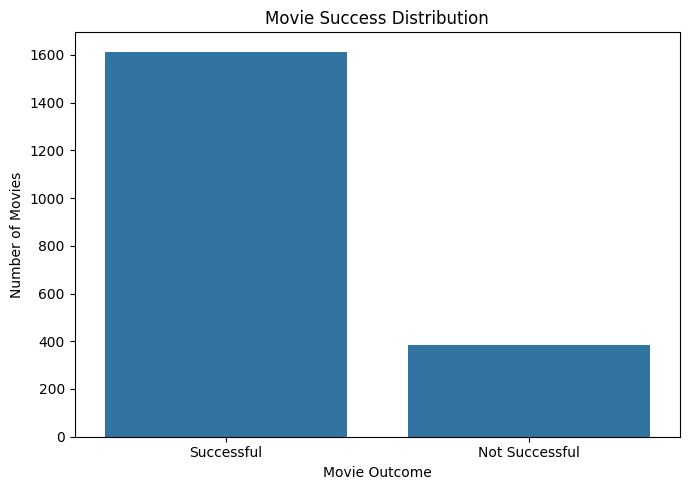

In [21]:
# Visualizing Success Distribution
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="success_label"
)

plt.title("Movie Success Distribution")
plt.xlabel("Movie Outcome")
plt.ylabel("Number of Movies")
plt.tight_layout()
plt.show()

In [22]:
# Process genres
# Analyzing and Standardizing Movie Genres
df["genres"] = df["genres"].fillna("Unknown").astype(str)

df["genre_list"] = df["genres"].apply(
    lambda x: [
        genre.strip()
        for genre in x.split("|")
        if genre.strip()
    ]
)

df_genres = df.explode("genre_list").copy()

df_genres["genre"] = df_genres["genre_list"].str.strip()

display(
    df_genres[
        ["title", "genre"]
    ].head(10)
)

,title,genre
0,Movie 1,"[{'id': 10749, 'name': 'Romance'}]"
1,Movie 2,"[{'id': 18, 'name': 'Drama'}]"
2,Movie 3,"[{'id': 35, 'name': 'Comedy'}]"
3,Movie 4,"[{'id': 18, 'name': 'Drama'}]"
4,Movie 5,"[{'id': 35, 'name': 'Comedy'}]"
5,Movie 6,"[{'id': 10749, 'name': 'Romance'}]"
6,Movie 7,"[{'id': 12, 'name': 'Adventure'}]"
7,Movie 8,"[{'id': 28, 'name': 'Action'}]"
8,Movie 9,"[{'id': 27, 'name': 'Horror'}]"
9,Movie 10,"[{'id': 27, 'name': 'Horror'}]"


In [23]:
print(df.columns)
print(df['genre'].head())

Index(['budget', 'revenue', 'popularity', 'runtime', 'vote_average', 'title',
       'genres', 'genre', 'profit', 'ROI', 'profit_margin', 'success',
       'success_label', 'genre_list'],
      dtype='object')
0    Romance
1      Drama
2     Comedy
3      Drama
4     Comedy
Name: genre, dtype: object


In [24]:
print(df[['genres', 'genre', 'genre_list']].head())

                               genres    genre  \
0  [{'id': 10749, 'name': 'Romance'}]  Romance   
1       [{'id': 18, 'name': 'Drama'}]    Drama   
2      [{'id': 35, 'name': 'Comedy'}]   Comedy   
3       [{'id': 18, 'name': 'Drama'}]    Drama   
4      [{'id': 35, 'name': 'Comedy'}]   Comedy   

                             genre_list  
0  [[{'id': 10749, 'name': 'Romance'}]]  
1       [[{'id': 18, 'name': 'Drama'}]]  
2      [[{'id': 35, 'name': 'Comedy'}]]  
3       [[{'id': 18, 'name': 'Drama'}]]  
4      [[{'id': 35, 'name': 'Comedy'}]]  


In [25]:
df = df.drop(columns=['genres', 'genre_list'])

In [26]:
# Most common genres
# Analyzing the number of movies in each genre
genre_counts = (
    df["genre"]
    .value_counts()
    .reset_index()
)

genre_counts.columns = ["Genre", "Movie Count"]

display(genre_counts)

,Genre,Movie Count
0,Romance,220
1,Adventure,207
2,Science Fiction,205
3,Animation,203
4,Comedy,202
5,Horror,199
6,Drama,197
7,Thriller,194
8,Action,192
9,Unknown,181


### What all manipulations have you done and insights you found?

"First, I performed data quality checks on the 2,000 movie records. I checked data types, missing values, duplicate rows, duplicate movie titles, zero values, negative values, and outliers. There were no missing values, duplicate rows, or invalid negative/zero budget and revenue values.

I then preprocessed the genre column because it was stored as a list of dictionaries. I extracted the genre name into a clean categorical column and replaced empty genre values with 'Unknown'

For feature engineering, I created Profit, ROI, and Profit Margin to measure the financial performance of each movie. I also created a binary Success variable, where a movie is considered successful when its revenue exceeds its production budget.

During the initial analysis, I found that 80.7% of movies were classified as successful and 19.3% as not successful. I also identified potential outliers in budget, revenue, popularity, runtime, and ratings, but I retained them because they can represent legitimate movies rather than data errors.

The next stage of the analysis is to investigate which factors such as budget, popularity, ratings, runtime, and genre are associated with higher revenue and movie success, and then use those features for regression and classification models."

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1 : How is movie revenue distributed?

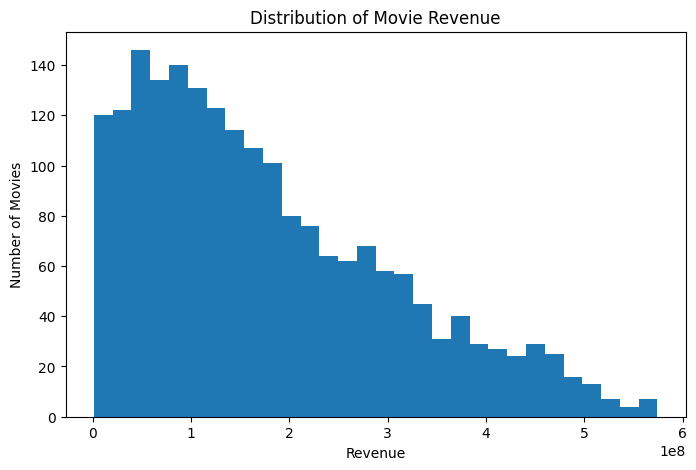

In [27]:
# Chart - 1 : Revenue Distribution
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(df['revenue'], bins=30)
plt.title('Distribution of Movie Revenue')
plt.xlabel('Revenue')
plt.ylabel('Number of Movies')
plt.show()

##### 1. Why did you pick the specific chart?

I used a histogram to understand the distribution, spread, and skewness of movie revenues.

##### 2. What is/are the insight(s) found from the chart?

Movie revenue is not normally distributed; it is strongly right-skewed.

Most movies are concentrated in the lower-to-middle revenue range, while relatively fewer movies generate very high revenue. The distribution extends up to approximately $575 million, indicating a small number of high-revenue movies.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Revenue performance is uneven across movies. A relatively small number of movies can generate substantially higher revenue than the majority.

Business Impact :
For a movie studio or investor:
1. Using only average revenue may give an overly optimistic picture of typical movie performance.
2. Revenue forecasting should account for the right-skewed distribution.
3. High-revenue movies should be analyzed separately to understand what characteristics contribute to exceptional performance.
4. For machine learning, we may later consider a log transformation of revenue if the skewness affects model performance.

#### Chart - 2 : How many movies generate high profits versus low or negative profits?

profit
Profit    1614
Loss       386
Name: count, dtype: int64


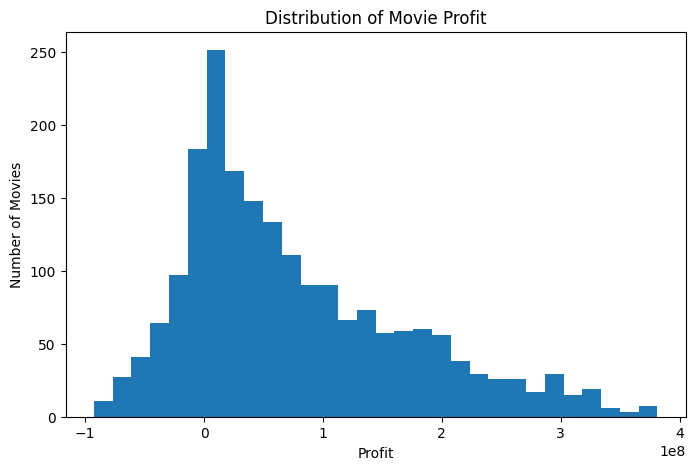

In [28]:
# Chart - 2 : Profit Distribution

# Count of Profit and Loss movies
print(df['profit'].apply(lambda x: 'Profit' if x > 0 else 'Loss').value_counts())

#high profits versus low or negative profits
plt.figure(figsize=(8, 5))
plt.hist(df['profit'], bins=30)
plt.title('Distribution of Movie Profit')
plt.xlabel('Profit')
plt.ylabel('Number of Movies')
plt.show()


##### 1. Why did you pick the specific chart?

I used a histogram to see how movie profits are distributed and identify profitable versus loss-making patterns.

##### 2. What is/are the insight(s) found from the chart?

The analysis shows that 80.7% of movies generated positive profit, while 19.3% operated at a loss. Profit is right-skewed, with most movies generating low-to-moderate profits and a smaller number of movies achieving exceptionally high profits. This indicates that movie profitability is uneven, and blockbuster movies can have a significant impact on overall profit performance.

1,614 movies (80.7%) are profitable.
386 movies (19.3%) operate at a loss.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Business Meaning

Most movies in this dataset generated revenue greater than their production budget, but nearly 1 in 5 movies failed to recover their production budget.

Business Impact

A studio should not evaluate movie performance using revenue alone. Profitability is important because a high-revenue movie can still perform poorly if its production budget is very high.

#### Chart - 3 : Does higher production budget tend to be associated with higher revenue?

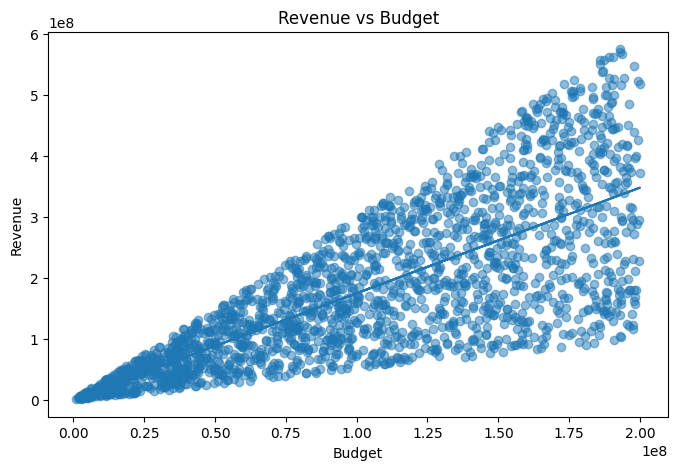

In [29]:
# Chart - 3 : Revenue vs Budget

x = df['budget']
y = df['revenue']

z = np.polyfit(x, y, 1)
p = np.poly1d(z)

plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.5)
plt.plot(x, p(x))
plt.title('Revenue vs Budget')
plt.xlabel('Budget')
plt.ylabel('Revenue')
plt.show()


##### 1. Why did you pick the specific chart?

I used a scatter plot because I wanted to visualize the relationship and correlation between budget and revenue.

##### 2. What is/are the insight(s) found from the chart?

Finding: Movie revenue generally increases as budget increases.

Evidence: The scatter plot shows a clear positive relationship and upward trend line.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Business Interpretation: Higher-budget movies tend to generate higher revenue, although outcomes vary considerably.

Business Impact: Budget can be an important factor when estimating potential revenue, but higher investment does not guarantee success.

#### Chart - 4 : Which movie genres generate the highest average revenue?

genre
Horror             1.917618e+08
Adventure          1.827697e+08
Animation          1.816994e+08
Drama              1.803174e+08
Action             1.800956e+08
Romance            1.762254e+08
Unknown            1.757446e+08
Comedy             1.720958e+08
Thriller           1.710711e+08
Science Fiction    1.688027e+08
Name: revenue, dtype: float64


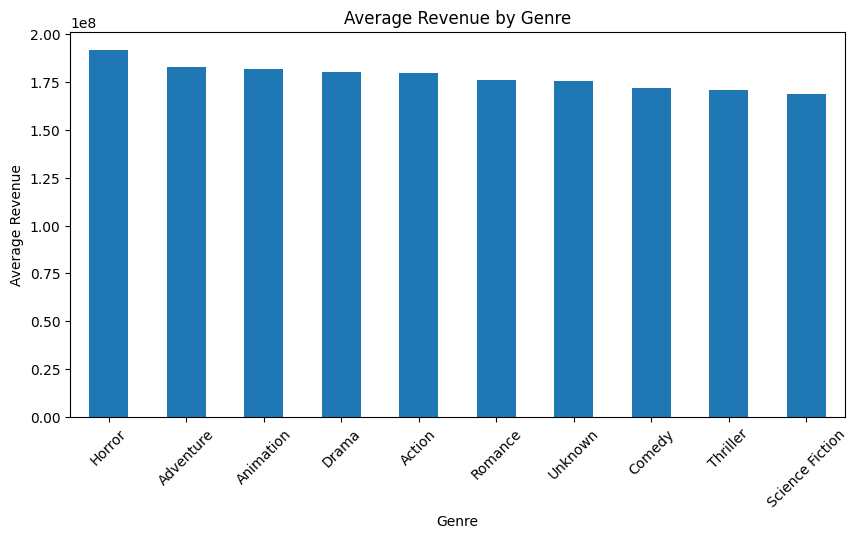

In [30]:
# Chart - 4 : Revenue by Genre
genre_revenue = (
    df.groupby('genre')['revenue']
      .mean()
      .sort_values(ascending=False)
)

print(genre_revenue)

plt.figure(figsize=(10, 5))
genre_revenue.plot(kind='bar')
plt.title('Average Revenue by Genre')
plt.xlabel('Genre')
plt.ylabel('Average Revenue')
plt.xticks(rotation=45)
plt.show()

In [31]:
profit_by_genre = (
    df.groupby('genre')['revenue']
      .mean()
      .sort_values(ascending=False)
      / 1000000
)

print(profit_by_genre.round(2))

genre
Horror             191.76
Adventure          182.77
Animation          181.70
Drama              180.32
Action             180.10
Romance            176.23
Unknown            175.74
Comedy             172.10
Thriller           171.07
Science Fiction    168.80
Name: revenue, dtype: float64


##### 1. Why did you pick the specific chart?

I used a bar chart to easily compare average revenue across different movie genres

##### 2. What is/are the insight(s) found from the chart?

Finding: Horror has the highest average revenue, while Science Fiction has the lowest among the listed genres.

Evidence: Horror averages around $192M, compared with approximately $169M for Science Fiction.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Business Interpretation: Genre appears to be associated with differences in average revenue performance.

Business Impact: Studios can consider genre-level revenue patterns when evaluating production and investment opportunities.

#### Chart - 5 : Which genres generate the highest average profit?

genre
Horror             8.602282e+07
Action             7.994800e+07
Unknown            7.848616e+07
Adventure          7.837564e+07
Animation          7.734454e+07
Drama              7.419618e+07
Thriller           7.314637e+07
Romance            7.227443e+07
Comedy             7.199837e+07
Science Fiction    7.035242e+07
Name: profit, dtype: float64


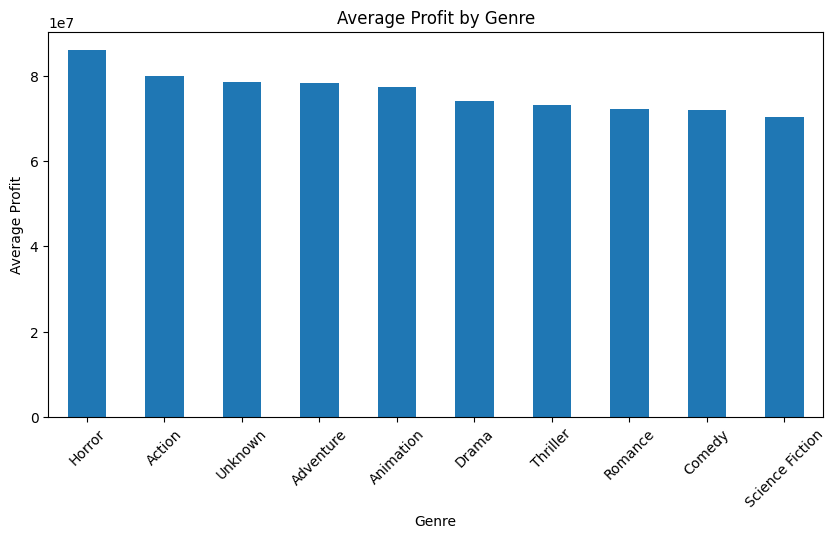

In [32]:
# Chart - 5 : Profit by Genre
genre_profit = (
    df.groupby('genre')['profit']
      .mean()
      .sort_values(ascending=False)
)

print(genre_profit)

plt.figure(figsize=(10, 5))
genre_profit.plot(kind='bar')
plt.title('Average Profit by Genre')
plt.xlabel('Genre')
plt.ylabel('Average Profit')
plt.xticks(rotation=45)
plt.show()

In [33]:
print(
    df.groupby('genre')['profit']
      .mean()
      .sort_values(ascending=False)
)

genre
Horror             8.602282e+07
Action             7.994800e+07
Unknown            7.848616e+07
Adventure          7.837564e+07
Animation          7.734454e+07
Drama              7.419618e+07
Thriller           7.314637e+07
Romance            7.227443e+07
Comedy             7.199837e+07
Science Fiction    7.035242e+07
Name: profit, dtype: float64


In [34]:
profit_by_genre = (
    df.groupby('genre')['profit']
      .mean()
      .sort_values(ascending=False)
      / 1000000
)

print(profit_by_genre.round(2))

genre
Horror             86.02
Action             79.95
Unknown            78.49
Adventure          78.38
Animation          77.34
Drama              74.20
Thriller           73.15
Romance            72.27
Comedy             72.00
Science Fiction    70.35
Name: profit, dtype: float64


##### 1. Why did you pick the specific chart?

I used a bar chart to compare the average profit generated by each genre.

##### 2. What is/are the insight(s) found from the chart?

Finding: Horror has the highest average profit, while Science Fiction has the lowest.

Evidence: Horror averages approximately $86.0M profit, compared with $70.4M for Science Fiction.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Business Interpretation: Horror movies generate stronger average profit relative to other genres in this dataset.

Business Impact: Studios could consider Horror as a potentially attractive genre for profit-focused investments, while evaluating Science Fiction more carefully for cost efficiency.

#### Chart - 6 : Which genres provide the best return relative to their production investment?

genre
Horror             0.832594
Unknown            0.781072
Action             0.758956
Science Fiction    0.758682
Adventure          0.745497
Animation          0.742161
Romance            0.738570
Drama              0.733392
Thriller           0.728343
Comedy             0.724658
Name: ROI, dtype: float64


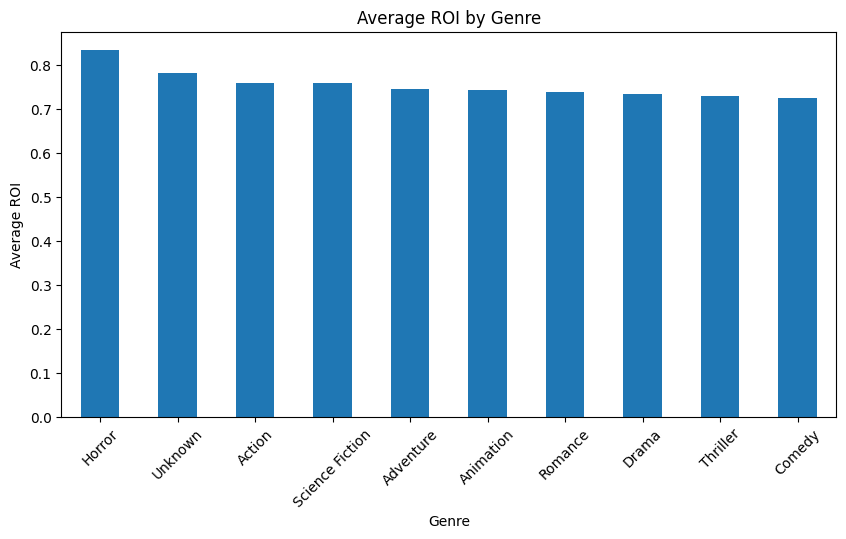

In [35]:
# Chart - 6 : ROI by Genre
genre_roi = (
    df.groupby('genre')['ROI']
      .mean()
      .sort_values(ascending=False)
)
print(genre_roi)

plt.figure(figsize=(10, 5))
genre_roi.plot(kind='bar')
plt.title('Average ROI by Genre')
plt.xlabel('Genre')
plt.ylabel('Average ROI')
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

I used a bar chart to rank and compare the average return on investment across genres

##### 2. What is/are the insight(s) found from the chart?

Horror has the highest average ROI among the analyzed genres.

Horror has an average ROI of 0.83, compared with 0.76 for Action and 0.76 for Science Fiction.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Business Interpretation - Horror movies generate relatively higher returns compared with their production investment.

Business Impact - Studios can consider Horror as a potentially capital-efficient genre when aiming for stronger returns with controlled budgets.

#### Chart - 7 : Which genres have the highest probability of generating revenue above production budget?

genre
Drama              0.822335
Horror             0.819095
Animation          0.812808
Unknown            0.812155
Comedy             0.811881
Thriller           0.809278
Romance            0.809091
Adventure          0.801932
Action             0.786458
Science Fiction    0.785366
Name: success, dtype: float64
genre
Drama              82.233503
Horror             81.909548
Animation          81.280788
Unknown            81.215470
Comedy             81.188119
Thriller           80.927835
Romance            80.909091
Adventure          80.193237
Action             78.645833
Science Fiction    78.536585
Name: success, dtype: float64


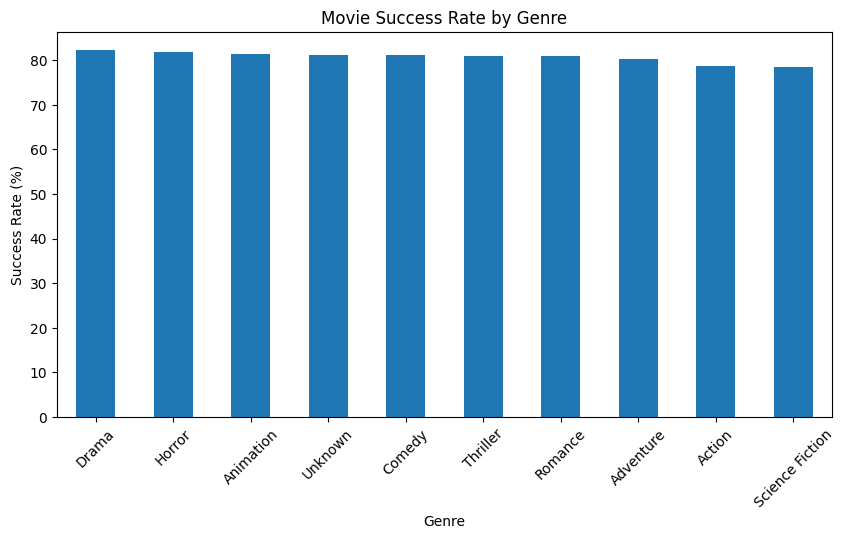

In [36]:
# Chart - 7 : Success Rate by Genre
success_by_genre = (
    df.groupby('genre')['success']
      .mean()
      .sort_values(ascending=False)
)

print(success_by_genre)

# converting success rate to percentage
success_rate = success_by_genre * 100

print(success_rate)

plt.figure(figsize=(10, 5))
success_rate.plot(kind='bar')
plt.title('Movie Success Rate by Genre')
plt.xlabel('Genre')
plt.ylabel('Success Rate (%)')
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

I used a bar chart to compare the percentage of successful movies across genres

##### 2. What is/are the insight(s) found from the chart?

Drama has the highest success rate, while Science Fiction has the lowest among the listed genres.

Drama: 82.23%, Horror: 81.91%, Animation: 81.28%; Science Fiction: 78.54%, Action: 78.65%.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Business Interpretation - Drama and Horror show relatively higher success rates, suggesting these genres more consistently meet the defined success criteria.

Business Impact - Studios can prioritize Drama and Horror when seeking genres with higher historical success rates, while treating this as a supporting factor alongside budget, audience demand, and ROI.

#### Chart - 8 : Which numerical factors have the strongest relationship with movie revenue?

revenue          1.000000
profit           0.919153
budget           0.759848
ROI              0.555020
profit_margin    0.495269
popularity       0.014076
vote_average    -0.005221
runtime         -0.068730
Name: revenue, dtype: float64


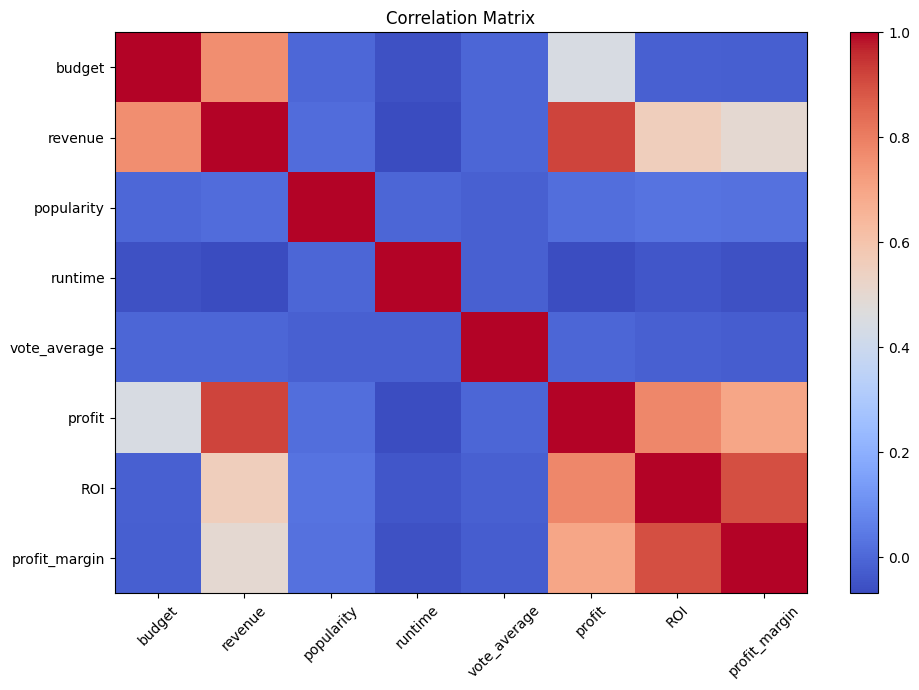

In [37]:
# Chart - 8 : Correlation Analysis
numeric_cols = [
    'budget',
    'revenue',
    'popularity',
    'runtime',
    'vote_average',
    'profit',
    'ROI',
    'profit_margin'
]

correlation = df[numeric_cols].corr()

print(correlation['revenue'].sort_values(ascending=False))

plt.figure(figsize=(10, 7))
plt.imshow(correlation, cmap='coolwarm', aspect='auto')
plt.colorbar()

plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=45)
plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

I used a correlation heatmap to quickly identify the strength and direction of relationships between numerical variables

##### 2. What is/are the insight(s) found from the chart?

Profit had the strongest correlation with revenue at approximately 0.92, followed by budget at approximately 0.76. In contrast, popularity and vote average had almost no linear correlation with revenue

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 9 : Are more popular movies associated with higher revenue?

0.01407615564388472


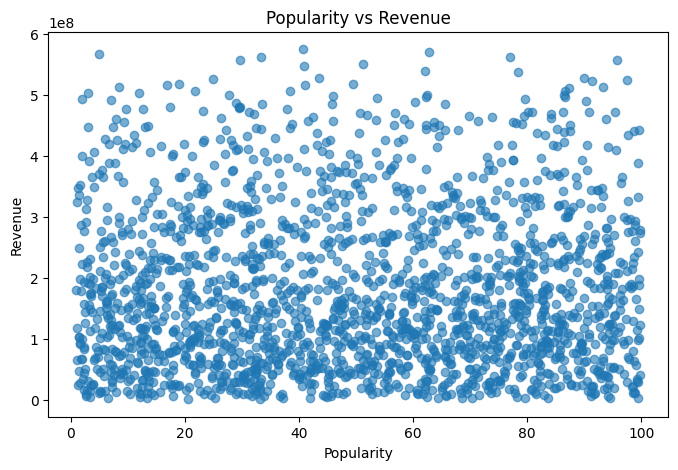

Popularity-Revenue Correlation: 0.01407615564388472


In [38]:
# Chart - 9 : Popularity vs Revenue
# popularity and revenue correlation
print(df['popularity'].corr(df['revenue']))

plt.figure(figsize=(8, 5))
plt.scatter(df['popularity'], df['revenue'], alpha=0.6)
plt.title('Popularity vs Revenue')
plt.xlabel('Popularity')
plt.ylabel('Revenue')
plt.show()

print(
    "Popularity-Revenue Correlation:",
    df['popularity'].corr(df['revenue'])
)


##### 1. Why did you pick the specific chart?

I used a scatter plot to determine whether movie popularity has a meaningful relationship with revenue

##### 2. What is/are the insight(s) found from the chart?

Popularity has almost no relationship with revenue.

Correlation = 0.014, which is very close to 0.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Business Interpretation - A movie being more popular does not necessarily mean it will generate higher revenue in this dataset.

Business Impact - Studios should not rely on popularity alone to predict revenue; budget, genre, and other business factors should also be considered.

#### Chart - 10 : Do higher audience ratings tend to be associated with higher movie revenue?

-0.005221086083612682


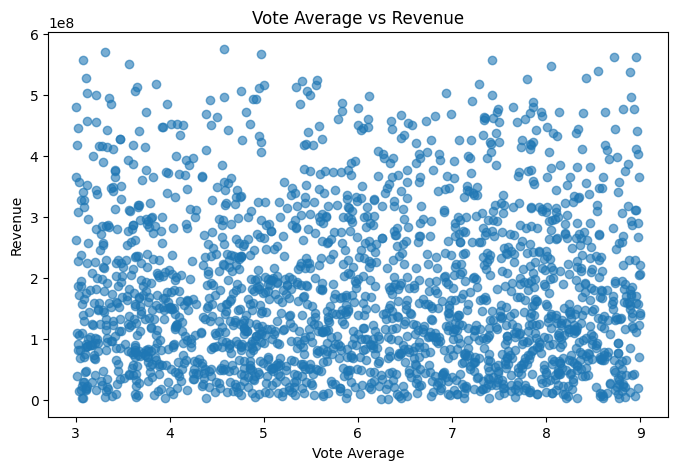

Vote Average-Revenue Correlation: -0.005221086083612682


In [39]:
# Chart - 10 : Vote Average vs Revenue
# vote average and revenue correlation
print(df['vote_average'].corr(df['revenue']))

plt.figure(figsize=(8, 5))
plt.scatter(df['vote_average'], df['revenue'], alpha=0.6)
plt.title('Vote Average vs Revenue')
plt.xlabel('Vote Average')
plt.ylabel('Revenue')
plt.show()

print(
    "Vote Average-Revenue Correlation:",
    df['vote_average'].corr(df['revenue'])
)


##### 1. Why did you pick the specific chart?

I used a scatter plot to examine whether audience ratings have a relationship with movie revenue

##### 2. What is/are the insight(s) found from the chart?

Audience rating has almost no relationship with revenue.

Correlation = −0.005, which is essentially zero.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Business Interpretation - Higher-rated movies do not necessarily generate higher revenue in this dataset.

Business Impact - Ratings can support content evaluation, but should not be treated as a strong revenue predictor.

In [40]:
df.columns

Index(['budget', 'revenue', 'popularity', 'runtime', 'vote_average', 'title',
       'genre', 'profit', 'ROI', 'profit_margin', 'success', 'success_label'],
      dtype='object')

## ***Feature Selection***

In [41]:
# Feature Selection + Preprocessing + Train/Test Split

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Regression target
X = df[['budget', 'popularity', 'runtime', 'vote_average', 'genre']]
y = df['revenue']

# Feature types
numeric_features = ['budget', 'popularity', 'runtime', 'vote_average']
categorical_features = ['genre']

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

# Train/Test Split - 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

# Preprocessing pipeline
preprocessing_pipeline = Pipeline([
    ('preprocessor', preprocessor)
])

# Fit preprocessing only on training data
X_train_processed = preprocessing_pipeline.fit_transform(X_train)
X_test_processed = preprocessing_pipeline.transform(X_test)

print("Processed training data:", X_train_processed.shape)
print("Processed testing data:", X_test_processed.shape)

Training data: (1600, 5)
Testing data: (400, 5)
Processed training data: (1600, 14)
Processed testing data: (400, 14)


Training data: (1600, 5)
1,600 movies are being used to train the model.
5 selected features: budget, popularity, runtime, vote_average, genre.

Testing data: (400, 5)
400 movies are reserved to evaluate the model on unseen data.
That's exactly an 80/20 split of 2,000 movies.

Processed training data: (1600, 14)
After preprocessing, your 5 original features became 14 numerical features.
This happened because genre was converted into multiple columns through One-Hot Encoding.

Processed testing data: (400, 14)
The test data was transformed using the same preprocessing learned from the training data, which is the correct approach.

## ***Regression Model***

In [42]:
# Regression Model - Linear Regression

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create and train the model
regression_model = LinearRegression()

regression_model.fit(X_train_processed, y_train)

# Predict revenue
y_pred = regression_model.predict(X_test_processed)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Linear Regression Model Performance")
print("-----------------------------------")
print(f"MAE  : {mae:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"R²   : {r2:.4f}")

Linear Regression Model Performance
-----------------------------------
MAE  : 66,658,141.16
RMSE : 87,368,610.49
R²   : 0.5894


Finding - The Linear Regression model provides a reasonable baseline but has significant prediction error.

Evidence - R² = 0.5894, meaning the model explains approximately 58.94% of revenue variation, while the average absolute prediction error is approximately $66.66M.

Business Interpretation - Movie revenue is influenced by factors beyond the current features (budget, popularity, runtime, vote_average, and genre).

Business Impact - The model can provide an initial revenue estimate, but it should not yet be relied on as the final prediction model for investment decisions.

## ***Random Forest Regression model***

In [43]:
# Random Forest Regression

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

# Train the model
rf_model.fit(X_train_processed, y_train)

# Predict revenue
rf_pred = rf_model.predict(X_test_processed)

# Evaluate the model
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Regression Model Performance")
print("------------------------------------------")
print(f"MAE  : {rf_mae:,.2f}")
print(f"RMSE : {rf_rmse:,.2f}")
print(f"R²   : {rf_r2:.4f}")

Random Forest Regression Model Performance
------------------------------------------
MAE  : 68,670,064.32
RMSE : 92,089,535.37
R²   : 0.5439


Finding - Linear Regression is the better-performing model among the two tested models.

Evidence - Linear Regression achieved R² = 0.5894, compared with 0.5439 for Random Forest. It also had lower MAE and RMSE.

Business Interpretation - For this dataset and selected features, the relationship between the predictors and revenue is captured better by the simpler Linear Regression model than by Random Forest.

Business Impact - We can use Linear Regression as the current revenue prediction model, while recognizing that its predictions still have substantial error.

R² of 0.5894 means the model explains about 58.94% of the variation in revenue. There is still substantial unexplained variation, so we should not present it as a highly accurate revenue predictor.

## ***Regression Model Evaluation***

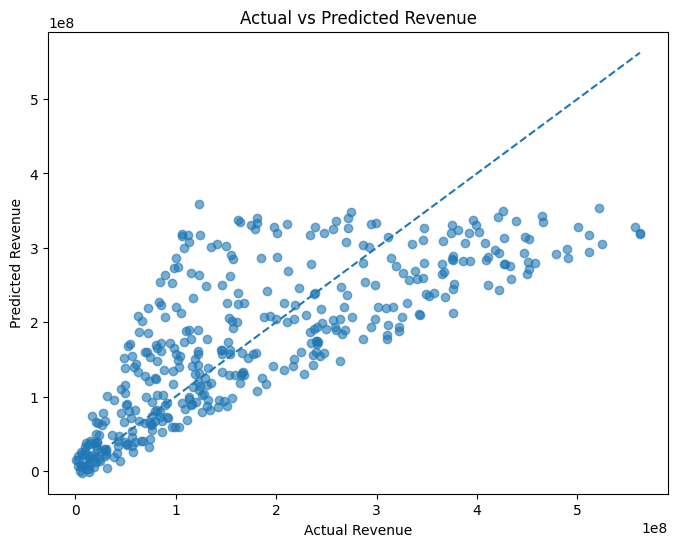

In [44]:
#Since Linear Regression performed better, we'll use it as the current revenue prediction model.
#Actual vs Predicted Revenue

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")
plt.title("Actual vs Predicted Revenue")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.show()

In [45]:
# Compare actual and predicted revenue

comparison = pd.DataFrame({
    'Actual Revenue': y_test.values,
    'Predicted Revenue': y_pred
})

comparison['Error'] = comparison['Actual Revenue'] - comparison['Predicted Revenue']
comparison['Absolute Error'] = abs(comparison['Error'])

print(comparison.head(10))

   Actual Revenue  Predicted Revenue         Error  Absolute Error
0        70598428       9.924362e+07 -2.864519e+07    2.864519e+07
1        38943371       1.897840e+07  1.996497e+07    1.996497e+07
2        98569187       1.657508e+08 -6.718164e+07    6.718164e+07
3       490775674       2.857332e+08  2.050425e+08    2.050425e+08
4       241003264       1.933503e+08  4.765296e+07    4.765296e+07
5        23360274       1.632797e+07  7.032304e+06    7.032304e+06
6       237373956       2.381380e+08 -7.640387e+05    7.640387e+05
7        86180740       5.176747e+07  3.441327e+07    3.441327e+07
8       146034348       2.495869e+08 -1.035526e+08    1.035526e+08
9        84102950       7.903708e+07  5.065873e+06    5.065873e+06


Actual vs Predicted Revenue — Interpretation :

Finding - The model predicts revenue reasonably for some movies but has substantial errors for high-revenue movies.

Evidence -
Movie 6: Actual $237.37M vs Predicted $238.14M → very close.
Movie 5: Actual $23.36M vs Predicted $16.33M → error of $7.03M.
Movie 4: Actual $490.78M vs Predicted $285.73M → error of $205.04M.
Movie 9: Actual $146.03M vs Predicted $249.59M → error of $103.55M.

Business Interpretation - The model can estimate revenue reasonably for some movies, but it struggles with very high-revenue or unusual movies, which contributes to the relatively high MAE and RMSE.

Business Impact - The model can be used as an initial revenue estimation tool, but studios should not rely on it alone for major investment decisions, especially for potential blockbuster movies.

Note: errors show that the model sometimes underpredicts and sometimes overpredicts:

Actual > Predicted - Underprediction
Actual < Predicted - Overprediction

Regression evaluation conclusion

Linear Regression explains 58.94% of revenue variation, but substantial prediction errors remain, particularly for high-revenue movies.

## ***Classification - Feature Selection, Preprocessing and Train/Test Split***

In [46]:
# Classification - Feature Selection, Preprocessing and Train/Test Split

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Features and target
X_class = df[['budget', 'popularity', 'runtime', 'vote_average', 'genre']]
y_class = df['success']

# Feature types
numeric_features_class = ['budget', 'popularity', 'runtime', 'vote_average']
categorical_features_class = ['genre']

# Preprocessing
preprocessor_class = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features_class),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features_class)
    ]
)

# Train/Test Split - 80/20
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_class,
    y_class,
    test_size=0.20,
    random_state=42,
    stratify=y_class
)

# Preprocessing pipeline
classification_pipeline = Pipeline([
    ('preprocessor', preprocessor_class)
])

# Fit only on training data
X_train_class_processed = classification_pipeline.fit_transform(X_train_class)
X_test_class_processed = classification_pipeline.transform(X_test_class)

print("Training data:", X_train_class.shape)
print("Testing data:", X_test_class.shape)
print("Processed training data:", X_train_class_processed.shape)
print("Processed testing data:", X_test_class_processed.shape)


Training data: (1600, 5)
Testing data: (400, 5)
Processed training data: (1600, 14)
Processed testing data: (400, 14)


1,600 movies - training
400 movies - testing
5 original features - budget, popularity, runtime, vote_average, genre
14 processed features - after scaling numerical variables and one-hot encoding genre
stratify=y_class - maintains a similar proportion of successful/unsuccessful movies in both training and testing datasets.

#### Logistic Regression Classification Model

In [47]:
# Logistic Regression Classification Model

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Create and train the model
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_class_processed, y_train_class)

# Predict success
y_pred_class = logistic_model.predict(X_test_class_processed)

# Evaluation metrics
accuracy = accuracy_score(y_test_class, y_pred_class)
precision = precision_score(y_test_class, y_pred_class)
recall = recall_score(y_test_class, y_pred_class)
f1 = f1_score(y_test_class, y_pred_class)

print("Logistic Regression Classification Performance")
print("----------------------------------------------")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_class, y_pred_class))

print("\nClassification Report:")
print(classification_report(y_test_class, y_pred_class))

Logistic Regression Classification Performance
----------------------------------------------
Accuracy  : 0.8075
Precision : 0.8075
Recall    : 1.0000
F1 Score  : 0.8935

Confusion Matrix:
[[  0  77]
 [  0 323]]

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        77
           1       0.81      1.00      0.89       323

    accuracy                           0.81       400
   macro avg       0.40      0.50      0.45       400
weighted avg       0.65      0.81      0.72       400



| Metric         |     Result | Interpretation                                         |
| -------------- | ---------: | ------------------------------------------------------ |
| Accuracy       | **80.75%** | 80.75% of predictions are correct overall              |
| Precision      | **80.75%** | 80.75% of predicted successes were actually successful |
| Recall         |   **100%** | It identified all actual successful movies             |
| F1 Score       | **89.35%** | High overall score for the positive class              |
| Class 0 Recall |     **0%** | It failed to identify any unsuccessful movies          |



Confusion Matrix:
[[  0   77]
 [  0  323]]

Meaning:

True Negatives = 0
False Positives = 77
False Negatives = 0
True Positives = 323

So the model predicted: 400/400 movies as successful.
This explains why you have 100% recall but 0% recall for unsuccessful movies.

Target distribution is likely imbalanced:
Successful = 323 / 400 = 80.75%
Unsuccessful = 77 / 400 = 19.25%

A model can achieve about 80.75% accuracy simply by predicting the majority class every time.
So don't use 80.75% accuracy alone to claim the classification model is good.

Finding - The model achieves 80.75% accuracy but is biased toward predicting movies as successful.

Evidence - All 323 successful movies were correctly identified, but all 77 unsuccessful movies were incorrectly classified as successful.

Business Impact - This model is not suitable for business decision-making yet, because recommending almost every movie as successful could lead to poor investment decisions.

#### Random Forest Classification Model

In [48]:
# Random Forest Classification Model

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Create Random Forest model
rf_classifier = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Train the model
rf_classifier.fit(X_train_class_processed, y_train_class)

# Predict success
rf_class_pred = rf_classifier.predict(X_test_class_processed)

# Evaluation metrics
rf_accuracy = accuracy_score(y_test_class, rf_class_pred)
rf_precision = precision_score(y_test_class, rf_class_pred)
rf_recall = recall_score(y_test_class, rf_class_pred)
rf_f1 = f1_score(y_test_class, rf_class_pred)

print("Random Forest Classification Performance")
print("-----------------------------------------")
print(f"Accuracy  : {rf_accuracy:.4f}")
print(f"Precision : {rf_precision:.4f}")
print(f"Recall    : {rf_recall:.4f}")
print(f"F1 Score  : {rf_f1:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_class, rf_class_pred))

print("\nClassification Report:")
print(classification_report(y_test_class, rf_class_pred))

Random Forest Classification Performance
-----------------------------------------
Accuracy  : 0.8100
Precision : 0.8095
Recall    : 1.0000
F1 Score  : 0.8947

Confusion Matrix:
[[  1  76]
 [  0 323]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.01      0.03        77
           1       0.81      1.00      0.89       323

    accuracy                           0.81       400
   macro avg       0.90      0.51      0.46       400
weighted avg       0.85      0.81      0.73       400



| Metric         | Logistic Regression | Random Forest | Better        |
| -------------- | ------------------: | ------------: | ------------- |
| Accuracy       |              80.75% |    **81.00%** | Random Forest |
| Precision      |              80.75% |    **80.95%** | Random Forest |
| Recall         |                100% |          100% | Same          |
| F1 Score       |              89.35% |    **89.47%** | Random Forest |
| Class 0 Recall |                  0% |        **1%** | Random Forest |


Random Forest model performed only slightly better than Logistic Regression, but it still has the same major problem: it predicts almost every movie as successful.

Random Forest's confusion matrix:

[[  1  76]
 [  0 323]]

Out of 77 unsuccessful movies, the model correctly identified only 1.
The model still fails to distinguish unsuccessful movies effectively.

Finding - Random Forest slightly outperforms Logistic Regression, but both models are heavily biased toward predicting movies as successful.

Evidence - Random Forest correctly identifies 323/323 successful movies, but only 1/77 unsuccessful movies.

Business Impact - The current classification model should not yet be used to make investment decisions, because it could classify most potentially unsuccessful movies as successful.

#### Improve the classification model.

In [49]:
# investigating on how success was created and check its class distribution first.
print(df['success'].value_counts())
print(df['success'].value_counts(normalize=True) * 100)

success
1    1614
0     386
Name: count, dtype: int64
success
1    80.7
0    19.3
Name: proportion, dtype: float64


In [50]:
# inspect the relationship between success and the underlying financial variables using mean
print(df.groupby('success')[['budget', 'revenue', 'profit', 'ROI', 'profit_margin']].mean())

               budget       revenue        profit       ROI  profit_margin
success                                                                   
0        1.056214e+08  7.905122e+07 -2.657017e+07 -0.255762      -0.397362
1        1.010362e+08  2.017355e+08  1.006993e+08  0.995448       0.450732


In [51]:
# inspect the relationship between success and the underlying financial variables using median

print(df.groupby('success')[['budget', 'revenue', 'profit', 'ROI']].median())

              budget      revenue      profit       ROI
success                                                
0        109973762.5   78119984.0 -20448117.5 -0.251039
1        100496326.0  184838585.0  73999463.0  0.992678


## ***Why classification model is struggling***

| Metric  | Unsuccessful |   Successful |
| ------- | -----------: | -----------: |
| Budget  | **$109.97M** | **$100.50M** |
| Revenue |  **$78.12M** | **$184.84M** |
| Profit  | **−$20.45M** |  **$74.00M** |
| ROI     |  **−25.10%** |   **99.27%** |


Finding - Successful movies generate substantially higher revenue and profit despite having a lower median budget than unsuccessful movies.

Evidence - Successful movies have median revenue of $184.84M vs $78.12M for unsuccessful movies, while median budget is $100.50M vs $109.97M.

Business Interpretation - Higher production spending alone does not guarantee success. Revenue generation relative to investment is much more important.

Business Impact - Studios should focus on maximizing audience demand and revenue potential rather than simply increasing production budgets.

The classification models struggled to identify unsuccessful movies because success is defined directly by post-release revenue relative to budget, while revenue is excluded from the predictive features to prevent data leakage."

I identified target leakage risk during feature selection and excluded revenue-derived variables. This revealed that pre-release features alone had limited ability to predict a post-release profitability-based success definition.

## ***Final Model Evaluation***

Regression — Revenue Prediction

Selected model: Linear Regression

MAE: $66.66M
RMSE: $87.37M
R²: 0.5894

Conclusion: The model explains approximately 58.94% of revenue variation, but prediction errors are substantial, particularly for high-revenue movies.

Classification — Success Prediction

Selected model: Random Forest Classifier

Accuracy: 81.00%
Precision: 80.95%
Recall: 100%
F1: 89.47%

However, the confusion matrix:

[[  1  76]
 [  0 323]]

shows that it correctly identified only 1 of 77 unsuccessful movies.

Classification limitation

Your success definition is:

success = 1 if revenue > budget

Because revenue is excluded from the predictors to prevent leakage, the available pre-release features have limited ability to predict this post-release financial outcome.



## ***Business Recommendations***

Business Recommendations

Based on your EDA and modeling results:

Recommendation 1 — Focus on profitability, not just revenue

Horror showed the highest average ROI (83.26%) and average profit (~$86M).

Action: Consider genres that demonstrate strong returns relative to investment.

Recommendation 2 — Budget matters, but spending more doesn't guarantee success

Budget had a strong positive correlation with revenue (0.76), but successful movies had a lower median budget than unsuccessful movies.

Action: Optimize budget allocation instead of simply increasing production spending.

Recommendation 3 — Don't rely solely on popularity or ratings
Popularity ↔ Revenue: 0.014
Vote Average ↔ Revenue: −0.005

Both are essentially zero in this dataset.

Action: Use popularity and ratings as supporting indicators rather than primary revenue predictors.

Recommendation 4 — Use revenue prediction as a planning tool

The Linear Regression model has R² = 0.5894.

Action: Use predicted revenue as an initial financial estimate, not as a guaranteed outcome.

Recommendation 5 — Treat classification predictions cautiously

The classification model struggles to identify unsuccessful movies.

Action: Do not use the current success classifier as a standalone investment decision tool.

## ***Save the trained models and preprocessing pipelines as .pkl files using joblib.***

In [52]:
import joblib

# Save Regression Model
joblib.dump(regression_model, "linear_regression_model.pkl")

# Save Regression Preprocessor
joblib.dump(preprocessing_pipeline, "regression_preprocessor.pkl")

# Save Classification Model
joblib.dump(rf_classifier, "random_forest_classifier.pkl")

# Save Classification Preprocessor
joblib.dump(classification_pipeline, "classification_preprocessor.pkl")

print("All models and preprocessors saved successfully.")

All models and preprocessors saved successfully.


#### Model diagnostics / threshold analysis,

In [53]:
#Prediction count
import pandas as pd

results = pd.DataFrame({
    "Actual": y_test_class.values,
    "Predicted": rf_class_pred
})

print(results["Predicted"].value_counts())

Predicted
1    399
0      1
Name: count, dtype: int64


Why we used it:
To check whether the classifier is predicting both classes or simply favoring one class.

What it revealed:
The model predicted:

Successful → 399
Unsuccessful → 1

This immediately exposed the classification imbalance/problem.

In [54]:
#Success probability analysis
probabilities = rf_classifier.predict_proba(X_test_class_processed)

probability_results = pd.DataFrame({
    "Actual": y_test_class.values,
    "Probability_Success": probabilities[:, 1],
    "Predicted": rf_class_pred
})

print(probability_results.sort_values("Probability_Success").head(10))

     Actual  Probability_Success  Predicted
339       0                0.500          0
51        0                0.510          1
251       0                0.520          1
351       1                0.545          1
278       0                0.545          1
217       0                0.575          1
151       1                0.595          1
34        1                0.600          1
25        1                0.610          1
154       1                0.610          1


Why we used it:
To see how confident the model is about its predictions instead of looking only at 0 or 1.

What it revealed:

Actual  Probability_Success
0       0.500
0       0.510
0       0.520
...

Most predictions were close to 50–60%, showing that the model has weak separation between successful and unsuccessful movies.

In [55]:
#Threshold analysis
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Get probability of class 1 (Successful)
success_prob = rf_classifier.predict_proba(X_test_class_processed)[:, 1]

threshold_results = []

for threshold in np.arange(0.30, 0.71, 0.05):
    predictions = (success_prob >= threshold).astype(int)

    threshold_results.append({
        "Threshold": round(threshold, 2),
        "Accuracy": accuracy_score(y_test_class, predictions),
        "Precision": precision_score(y_test_class, predictions, zero_division=0),
        "Recall": recall_score(y_test_class, predictions, zero_division=0),
        "F1 Score": f1_score(y_test_class, predictions, zero_division=0),
        "Unsuccessful Recall": recall_score(
            y_test_class,
            predictions,
            pos_label=0,
            zero_division=0
        )
    })

threshold_df = pd.DataFrame(threshold_results)

print(threshold_df.round(3))

   Threshold  Accuracy  Precision  Recall  F1 Score  Unsuccessful Recall
0       0.30     0.808      0.808   1.000     0.893                0.000
1       0.35     0.808      0.808   1.000     0.893                0.000
2       0.40     0.808      0.808   1.000     0.893                0.000
3       0.45     0.808      0.808   1.000     0.893                0.000
4       0.50     0.808      0.808   1.000     0.893                0.000
5       0.55     0.815      0.815   0.997     0.897                0.052
6       0.60     0.815      0.817   0.994     0.897                0.065
7       0.65     0.792      0.814   0.963     0.882                0.078
8       0.70     0.738      0.808   0.885     0.845                0.117


Why we used it:
The default classification threshold is 0.50. We tested different thresholds to see whether we could improve the model's ability to identify unsuccessful movies.

Your results showed:

Threshold	Accuracy	F1	Unsuccessful Recall
0.50	80.8%	89.3%	0.0%
0.60	81.5%	89.7%	6.5%
0.70	73.8%	84.5%	11.7%

We selected 0.60 because it provided the best overall combination among the tested thresholds, while slightly improving unsuccessful-movie detection.

However, 6.5% unsuccessful recall is still very low, so we should continue describing the classifier as limited.

In [56]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Log-transform revenue
y_train_log = np.log1p(y_train)

# Train model
log_regression_model = LinearRegression()
log_regression_model.fit(X_train_processed, y_train_log)

# Predict log revenue
y_pred_log = log_regression_model.predict(X_test_processed)

# Convert predictions back to original revenue scale
y_pred_log_original = np.expm1(y_pred_log)

# Prevent negative predictions
y_pred_log_original = np.maximum(y_pred_log_original, 0)

# Evaluate
log_mae = mean_absolute_error(y_test, y_pred_log_original)
log_rmse = np.sqrt(mean_squared_error(y_test, y_pred_log_original))
log_r2 = r2_score(y_test, y_pred_log_original)

print("Log-Transformed Linear Regression Performance")
print("---------------------------------------------")
print(f"MAE  : {log_mae:,.2f}")
print(f"RMSE : {log_rmse:,.2f}")
print(f"R²   : {log_r2:.4f}")

Log-Transformed Linear Regression Performance
---------------------------------------------
MAE  : 74,627,227.23
RMSE : 100,117,289.63
R²   : 0.4609


The original Linear Regression model was selected because it achieved the best test performance, with an R² of 0.5894, MAE of $66.66M, and RMSE of $87.37M. The log-transformed model was evaluated but performed worse and therefore was not selected for deployment.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

MovieIQ provides an interactive Streamlit tool where users can enter new movie details and receive predicted revenue and success probability.

This helps production or investment teams perform an initial data-driven risk assessment before making decisions.

# **Conclusion**

Overall, MovieIQ demonstrates an end-to-end predictive analytics workflow, from data preparation and exploratory analysis through feature engineering, predictive modeling, evaluation and deployment. The solution provides revenue estimates and success indicators while also identifying the limitations that should be considered before using the models for real-world investment decisions.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***